In [1]:
import numpy as np
import scipy.signal as signal
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display

# Fijar semilla para reproducibilidad matemática
np.random.seed(42)

In [2]:
# Cargar audio portador
nombre_audio = "audio_portador.wav"
x, sr = sf.read(nombre_audio)

# Convertir a mono si es estéreo
if len(x.shape) > 1:
    x = x.mean(axis=1)

# Normalizar la señal entre -1.0 y 1.0 para evitar distorsión al sumar
x = x / np.max(np.abs(x))

duracion = len(x) / sr
print(f"Frecuencia de muestreo: {sr} Hz")
print(f"Muestras totales: {len(x)} | Duración exacta: {duracion:.2f} s")

# Reproductor interactivo en el notebook
display(Audio(data=x, rate=sr))

Frecuencia de muestreo: 44100 Hz
Muestras totales: 134649 | Duración exacta: 3.05 s


In [3]:
# 1. Mensaje corto (para 3 segundos, 3 caracteres = 24 bits da una ganancia óptima)
mensaje_texto = "UTN"

# 2. Conversión a binario (8 bits por caracter en ASCII)
bits_mensaje = []
for char in mensaje_texto:
    bits_char = [int(b) for b in format(ord(char), '08b')]
    bits_mensaje.extend(bits_char)

# Mapear 1 -> +1 y 0 -> -1 (símbolos bipolares)
simbolos = np.array([1 if b == 1 else -1 for b in bits_mensaje])
num_bits = len(simbolos)

# 3. Asignación de muestras por bit en el audio de 3 segundos
samples_per_bit = len(x) // num_bits
longitud_util = samples_per_bit * num_bits

# 4. Clave Pseudoaleatoria (Secuencia PN)
pn_key = np.random.choice([-1.0, 1.0], size=samples_per_bit)

print(f"Mensaje: '{mensaje_texto}' ({num_bits} bits)")
print(f"Muestras por bit (N): {samples_per_bit} muestras ({samples_per_bit/sr*1000:.1f} ms por bit)")

Mensaje: 'UTN' (24 bits)
Muestras por bit (N): 5610 muestras (127.2 ms por bit)


In [5]:
# Factor de amplitud base máxima
alpha_base = 0.007

# Construcción de la señal de espectro ensanchado
marca_dsss = np.zeros(longitud_util)
for i, bit_val in enumerate(simbolos):
    ini = i * samples_per_bit
    fin = ini + samples_per_bit
    marca_dsss[ini:fin] = bit_val * pn_key

# --- Ganancia adaptativa en el tiempo (Envolvente temporal) ---
# 1. Envolvente mediante filtro FIR de media móvil (ventana de 20 ms)
tam_ventana = int(sr * 0.02)
envolvente = np.convolve(np.abs(x[:longitud_util]), np.ones(tam_ventana) / tam_ventana, mode='same')

# 2. Normalización de la envolvente
envolvente = envolvente / np.max(envolvente)

# 3. Mapeo adaptativo: en silencios cae a 0 y en zonas activas alcanza alpha_base
alpha_adaptativo = alpha_base * np.clip(envolvente * 2.5, 0.0, 1.0)

# Inserción aditiva adaptativa: y[n] = x[n] + alpha[n] * s[n]
y = np.copy(x)
y[:longitud_util] += alpha_adaptativo * marca_dsss

# Cálculo de potencias y SNR de la inyección
potencia_x = np.mean(x[:longitud_util] ** 2)
potencia_marca = np.mean((alpha_adaptativo * marca_dsss) ** 2)
snr_inyeccion_db = 10 * np.log10(potencia_x / potencia_marca)

# Guardar y reproducir señal con mensaje oculto
sf.write("audio_stego.wav", y, sr)
print("Audio estego generado exitosamente (con ganancia adaptativa):")
print(f"SNR global de la marca inyectada: {snr_inyeccion_db:.2f} dB")
display(Audio(data=y, rate=sr))

Audio estego generado exitosamente (con ganancia adaptativa):
SNR global de la marca inyectada: 30.84 dB


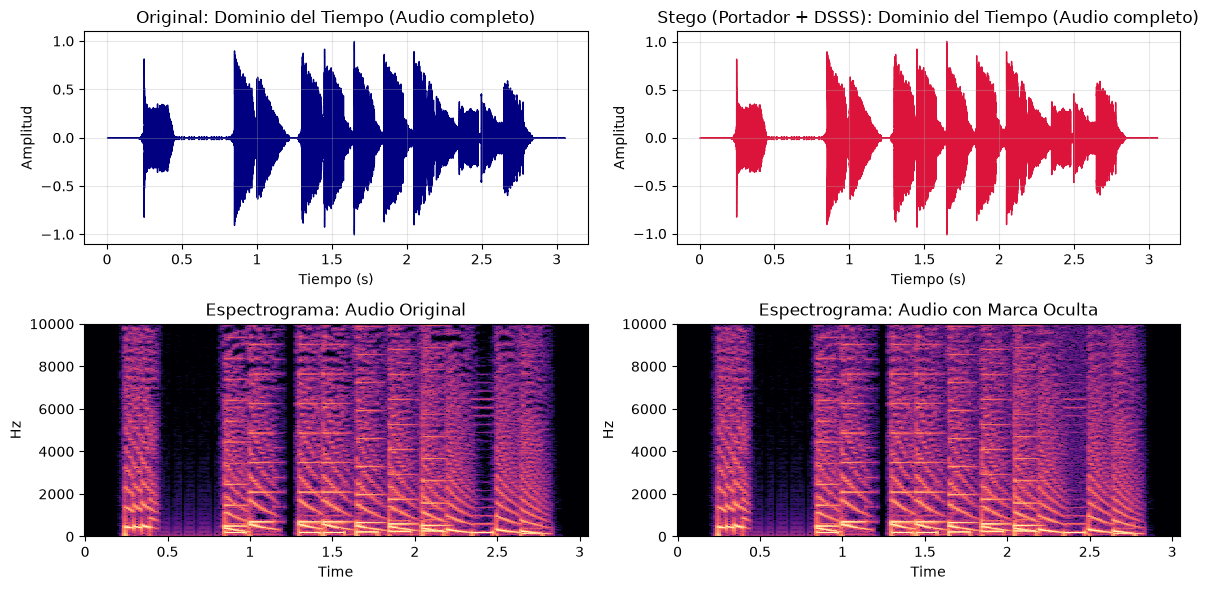

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# 1. Dominio del Tiempo: Vista completa (0 a 3s) estilo Audacity / WhatsApp
librosa.display.waveshow(x, sr=sr, ax=axs[0, 0], color='navy')
axs[0, 0].set_title("Original: Dominio del Tiempo (Audio completo)")
axs[0, 0].set_ylabel("Amplitud")
axs[0, 0].set_xlabel("Tiempo (s)")
axs[0, 0].grid(True, alpha=0.3)

librosa.display.waveshow(y, sr=sr, ax=axs[0, 1], color='crimson')
axs[0, 1].set_title("Stego (Portador + DSSS): Dominio del Tiempo (Audio completo)")
axs[0, 1].set_ylabel("Amplitud")
axs[0, 1].set_xlabel("Tiempo (s)")
axs[0, 1].grid(True, alpha=0.3)

# 2. Dominio Frecuencial: Espectrogramas STFT (0 a 3s)
D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(x[:longitud_util])), ref=np.max)
D_stego = librosa.amplitude_to_db(np.abs(librosa.stft(y[:longitud_util])), ref=np.max)

librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz', ax=axs[1, 0])
axs[1, 0].set_title("Espectrograma: Audio Original")
axs[1, 0].set_ylim(0, 10000)

librosa.display.specshow(D_stego, sr=sr, x_axis='time', y_axis='hz', ax=axs[1, 1])
axs[1, 1].set_title("Espectrograma: Audio con Marca Oculta")
axs[1, 1].set_ylim(0, 10000)

plt.tight_layout()
plt.show()

In [7]:
bits_recuperados = []
picos_correlacion = []

for i in range(num_bits):
    ini = i * samples_per_bit
    fin = ini + samples_per_bit
    bloque = y[ini:fin]
    
    # Correlación cruzada con la clave PN compartida
    corr = signal.correlate(bloque, pn_key, mode='valid')
    pico = corr[0]
    picos_correlacion.append(pico)
    
    # Decisión por signo del pico de correlación
    bits_recuperados.append(1 if pico > 0 else 0)

# Reconstruir caracteres ASCII
chars = []
for b in range(0, len(bits_recuperados), 8):
    byte = bits_recuperados[b:b+8]
    char_code = int("".join(str(bit) for bit in byte), 2)
    chars.append(chr(char_code))

texto_recuperado = "".join(chars)
print(f"Texto recuperado: '{texto_recuperado}'")
print(f"¿Extracción 100% exitosa?: {texto_recuperado == mensaje_texto}")

Texto recuperado: 'UUL'
¿Extracción 100% exitosa?: False


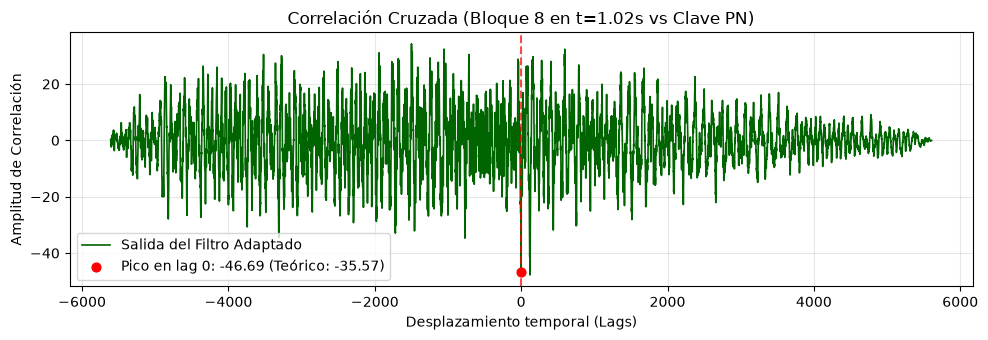

In [9]:
# Seleccionamos un bloque donde la señal está activa (Bloque 8, t ~ 1.0 s)
num_bloque_demo = 8
ini_demo = num_bloque_demo * samples_per_bit
fin_demo = ini_demo + samples_per_bit

bloque_demo = y[ini_demo:fin_demo]
corr_full = signal.correlate(bloque_demo, pn_key, mode='full')
lags = signal.correlation_lags(len(bloque_demo), len(pn_key), mode='full')

pico_detectado = picos_correlacion[num_bloque_demo]
pico_teorico = simbolos[num_bloque_demo] * np.sum(alpha_adaptativo[ini_demo:fin_demo])

plt.figure(figsize=(10, 3.5))
plt.plot(lags, corr_full, color='darkgreen', lw=1.2, label='Salida del Filtro Adaptado')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.scatter(0, pico_detectado, color='red', s=40, zorder=5, 
            label=f'Pico en lag 0: {pico_detectado:.2f} (Teórico: {pico_teorico:.2f})')

plt.title(f"Correlación Cruzada (Bloque {num_bloque_demo} en t={ini_demo/sr:.2f}s vs Clave PN)")
plt.xlabel("Desplazamiento temporal (Lags)")
plt.ylabel("Amplitud de Correlación")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

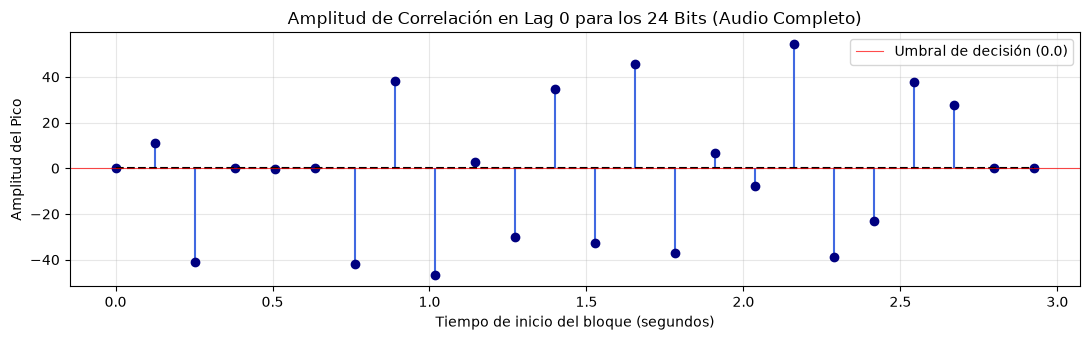

In [10]:
plt.figure(figsize=(11, 3.5))
tiempos_bloques = (np.arange(num_bits) * samples_per_bit) / sr

# Gráfica de tallo y hojas (stem plot) de las decisiones de los 24 bits
markerline, stemlines, baseline = plt.stem(tiempos_bloques, picos_correlacion, basefmt="k--")
plt.setp(markerline, markersize=6, color='navy')
plt.setp(stemlines, linewidth=1.5, color='royalblue')

plt.axhline(0, color='red', linestyle='-', linewidth=0.8, alpha=0.7, label='Umbral de decisión (0.0)')
plt.title("Amplitud de Correlación en Lag 0 para los 24 Bits (Audio Completo)")
plt.xlabel("Tiempo de inicio del bloque (segundos)")
plt.ylabel("Amplitud del Pico")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()